In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf

In [ ]:
from keras.layers import Input,Dense,Flatten
from keras.models import Model
from keras.optimizers import Adam
from keras.preprocessing import image
import numpy as np
import glob
from keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
from datetime import datetime
from keras.callbacks import ModelCheckpoint
from keras import applications
from keras.applications import MobileNetV2


In [ ]:
# Define the image size
IMAGE_SIZE = [224, 224, 3]

# Load the model
mobilenetv2 = MobileNetV2(include_top=False, input_shape=IMAGE_SIZE, weights='imagenet')

# Visualize the model summary
#mobilenetv2.summary()


9406464/9406464 [==============================] - 2s 0us/step


In [ ]:
for layer in mobilenetv2.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom head to the base model

x = mobilenetv2.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)

In [ ]:
model = Model(inputs=mobilenetv2.input, outputs=predictions)

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

In [ ]:

adam=Adam()

model.compile(loss='categorical_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])

In [ ]:
train_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Train/Case2'
test_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Test/Case2'

In [ ]:
from PIL import Image
import os

def verify_and_convert_images(directory):
    corrupted_images = []
    unconvertible_images = []
    for subdir, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(subdir, file)
            try:
                img = Image.open(file_path)
                img.verify()  # Verify the image integrity
            except (IOError, SyntaxError) as e:
                print(f"Corrupted image: {file_path}")
                corrupted_images.append(file_path)
                success = convert_to_jpg(file_path)
                if not success:
                    unconvertible_images.append(file_path)
    return corrupted_images, unconvertible_images

def convert_to_jpg(file_path):
    try:
        with Image.open(file_path) as img:
            # Convert image to RGB (JPG format)
            rgb_img = img.convert('RGB')

            # Save as JPG with the same name but .jpg extension
            new_file_path = os.path.splitext(file_path)[0] + '.jpg'
            rgb_img.save(new_file_path, 'JPEG')

            # Remove the original file if it's not already a jpg
            if file_path != new_file_path:
                os.remove(file_path)

            print(f"Converted {file_path} to {new_file_path}")
            return True
    except Exception as e:
        print(f"Error converting {file_path}: {e}")
        return False

def remove_files(file_paths):
    for file_path in file_paths:
        try:
            os.remove(file_path)
            print(f"Removed unconvertible image: {file_path}")
        except Exception as e:
            print(f"Error removing {file_path}: {e}")

In [ ]:
corrupted_train_images, unconvertible_train_images = verify_and_convert_images(train_path)
corrupted_test_images, unconvertible_test_images = verify_and_convert_images(test_path)

print(f"Found and attempted to convert {len(corrupted_train_images)} corrupted images in train set.")
print(f"Found and attempted to convert {len(corrupted_test_images)} corrupted images in test set.")
print(f"Unconvertible train images: {unconvertible_train_images}")
print(f"Unconvertible test images: {unconvertible_test_images}")

# Remove unconvertible images
remove_files(unconvertible_train_images)
remove_files(unconvertible_test_images)

Corrupted image: /content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_220103_0_917.jpeg
Error converting /content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_220103_0_917.jpeg: cannot identify image file '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_220103_0_917.jpeg'
Corrupted image: /content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_112401_0_8497.jpeg
Error converting /content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_112401_0_8497.jpeg: cannot identify image file '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_112401_0_8497.jpeg'
Corrupted image: /content/drive/Othercomputers/My Laptop/RoadImagesDataSet/DataSetV2/Train/ManHole/Water_20240323_112326_0_9025.jpeg
Error converting /content/drive/Othercomputers

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)

# Train data
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(224, 224),
                                              batch_size=64,
                                              class_mode='categorical')

# Test data
test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(224, 224),
                                            batch_size=64,
                                            class_mode='categorical')



Found 3341 images belonging to 3 classes.
Found 838 images belonging to 3 classes.


In [ ]:
output_layer = model.layers[-1]  # Assuming the output layer is the last layer in the model
num_classes = output_layer.output_shape[-1]  # Number of units in the output layer

print("Number of classes in the output layer:", num_classes)


Number of classes in the output layer: 3


Class weights

In [ ]:
import os
from sklearn.utils import class_weight
import numpy as np

# Path to your dataset
dataset_path = train_path

# Function to count images in each class directory
def count_images_in_classes(dataset_path):
    labels = []
    class_names = os.listdir(dataset_path)
    for class_index, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            num_images = len([img_name for img_name in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, img_name))])
            labels.extend([class_index] * num_images)
    return np.array(labels), class_names

# Count images and get labels
y_train, class_names = count_images_in_classes(dataset_path)

# Compute class weights
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))

# Print computed class weights
print("Computed class weights:")
print(class_weights_dict)


Computed class weights:
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}


In [ ]:
print(class_names)

['SpeedBreaker', 'ManHole', 'PotHoles', 'SolidWaste', 'SandDirt', 'CementTiles']


In [ ]:
batch_size=64

# Calculate steps_per_epoch

steps_per_epoch = train_set.samples // batch_size
if train_set.samples % batch_size != 0:
    steps_per_epoch += 1
print(steps_per_epoch)
# Calculate validation_steps
val_set=test_set
validation_steps = val_set.samples // batch_size
if val_set.samples % batch_size != 0:
    validation_steps += 1
print(validation_steps)

53
14


In [ ]:
# Define the file name for the model checkpoint
checkpoint_filepath = '/content/drive/MyDrive/Models/mobilenetv2_3class.keras'

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_best_only=True)

# Combine all callbacks
callbacks = [checkpoint]

# Start timing
start = datetime.now()

# Train the model
model_history = model.fit(train_set,
                          validation_data=test_set,
                          epochs=5,
                          steps_per_epoch = 53,
                          validation_steps = 14,
                          callbacks=callbacks)
# Calculate duration5
duration = datetime.now() - start

print('Total elapsed time:', duration)

Epoch 1/5
53/53 [==============================] - ETA: 0s - loss: 0.6235 - accuracy: 0.8105 
Epoch 1: val_loss improved from inf to 0.16865, saving model to /content/drive/MyDrive/Models/mobilenetv2_3class.keras
53/53 [==============================] - 3064s 58s/step - loss: 0.6235 - accuracy: 0.8105 - val_loss: 0.1686 - val_accuracy: 0.9403
Epoch 2/5
53/53 [==============================] - ETA: 0s - loss: 0.0948 - accuracy: 0.9731
Epoch 2: val_loss improved from 0.16865 to 0.07631, saving model to /content/drive/MyDrive/Models/mobilenetv2_3class.keras
53/53 [==============================] - 349s 7s/step - loss: 0.0948 - accuracy: 0.9731 - val_loss: 0.0763 - val_accuracy: 0.9714
Epoch 3/5
53/53 [==============================] - ETA: 0s - loss: 0.0571 - accuracy: 0.9832
Epoch 3: val_loss improved from 0.07631 to 0.06044, saving model to /content/drive/MyDrive/Models/mobilenetv2_3class.keras
53/53 [==============================] - 336s 6s/step - loss: 0.0571 - accuracy: 0.9832 - val

In [1]:
from keras.models import load_model
model = load_model("/content/drive/MyDrive/Models/mobilenetv2.keras")


In [2]:
import os

# Replace 'path_to_your_directory' with the actual path to your directory
directory_path = '/content/drive/Othercomputers/My Laptop/RoadImagesDataSet/Test'

# Get all folder names in the directory
class_labels= [f for f in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, f))]

print(class_labels)

['ManHole', 'CementTiles', 'SolidWaste', 'SandDirt', 'SpeedBreaker', 'WaterFilledPotholes', 'PotHoles']


In [3]:
test_path=directory_path

In [4]:
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
import numpy as np

your_directory = test_path
y_true=[]
y_pred=[]
for root, dirs, files in os.walk(your_directory):
    for file in files:
      img_path=os.path.join(root, file)

      remove=your_directory+'/'
      orginal_label=root.replace(remove,"")
      y_true.append(orginal_label)

      # Load and preprocess the image
      img = image.load_img(img_path, target_size=(224, 224))  # Replace target size with your model's expected input size
      img_array = image.img_to_array(img)
      img_array = np.expand_dims(img_array, axis=0)

      # Predict the class probabilities
      probabilities = model.predict(img_array)

      # Get the index of the class with the highest probability
      predicted_index = np.argmax(probabilities)

      # Get the name of the class
      predicted_class = class_labels[predicted_index]
      y_pred.append(predicted_class)



print(y_true)
print(y_pred)

1/1 [==============================] - 0s 22ms/step
['ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', 'ManHole', '

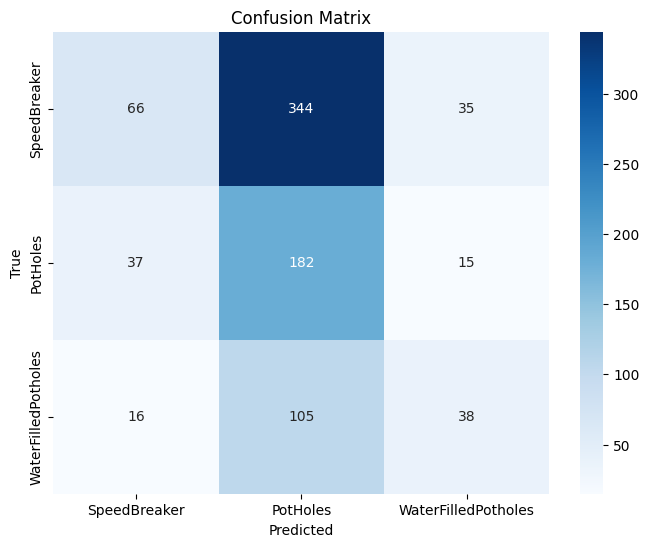

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn import metrics

# Assuming you have the true labels and predicted labels
true_labels = y_true# Replace with the true labels from your test set
predicted_labels =y_pred # Replace with the predicted labels from your model

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

                     precision    recall  f1-score   support

        CementTiles       0.14      0.24      0.18       300
            ManHole       0.14      0.16      0.15       163
           PotHoles       0.21      0.14      0.17       445
           SandDirt       0.10      0.35      0.16       106
         SolidWaste       0.17      0.18      0.17       173
       SpeedBreaker       0.16      0.02      0.03       234
WaterFilledPotholes       0.00      0.00      0.00       159

           accuracy                           0.15      1580
          macro avg       0.13      0.16      0.12      1580
       weighted avg       0.15      0.15      0.13      1580

